# Chapter 18 — Wi-Fi and Bluetooth for IoT: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the plots, then try the
> challenge tasks at the end of each section. All exercises run in Google
> Colab with no additional hardware.

| Exercise | Topic | Key technique |
|----------|-------|---------------|
| 18.1 | Wi-Fi link adaptation | IEEE 802.11ac MCS/sensitivity table (5 GHz) + log-distance path loss, outage probability |
| 18.2 | CSMA/CA contention | Bianchi's DCF saturation-throughput fixed point (solved over the full probability range) |
| 18.3 | BLE connection parameters | Connection-event energy model, real BLE SoC current draw |
| 18.4 | Bluetooth/Wi-Fi coexistence | BLE and BR/EDR channel-overlap analysis, Monte Carlo cross-check |


---
## Setup

The cell below defines the shared toolkit used throughout this notebook:
the IEEE 802.11ac MCS/sensitivity table and link-adaptation logic
(Exercise 18.1), Bianchi's DCF fixed-point equations (Exercise 18.2), a
BLE connection-event energy model built from published radio current-draw
figures (Exercise 18.3), and the 2.4 GHz channel maps used for the
Bluetooth/Wi-Fi coexistence analysis (Exercise 18.4).

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import norm
from scipy.integrate import quad

np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.6,
})

# ---------------------------------------------------------------------
# Ex. 18.1 toolkit: IEEE 802.11ac VHT MCS table, 20 MHz, 1 spatial
# stream, 800 ns guard interval. 802.11ac is a 5 GHz-only amendment, so
# all Exercise 18.1 calculations use a 5 GHz carrier. MCS9 is undefined
# for 20 MHz with 1 spatial stream (it is only valid at 20 MHz for 3 or
# 6 spatial streams), so the usable table has nine levels, MCS0-MCS8.
# Data rates: IEEE 802.11ac-2013, Table 22-30. Minimum receiver
# sensitivity: representative figures compiled from IEEE 802.11ac-2013
# Sec. 22.3.19.1 and industry reference tables; real radios vary by a
# few dB either side.
# ---------------------------------------------------------------------
MCS_TABLE = [
    dict(mcs=0, mod='BPSK',    coding='1/2', rate_mbps=6.5,  sens_dbm=-82),
    dict(mcs=1, mod='QPSK',    coding='1/2', rate_mbps=13.0, sens_dbm=-79),
    dict(mcs=2, mod='QPSK',    coding='3/4', rate_mbps=19.5, sens_dbm=-77),
    dict(mcs=3, mod='16-QAM',  coding='1/2', rate_mbps=26.0, sens_dbm=-74),
    dict(mcs=4, mod='16-QAM',  coding='3/4', rate_mbps=39.0, sens_dbm=-70),
    dict(mcs=5, mod='64-QAM',  coding='2/3', rate_mbps=52.0, sens_dbm=-66),
    dict(mcs=6, mod='64-QAM',  coding='3/4', rate_mbps=58.5, sens_dbm=-65),
    dict(mcs=7, mod='64-QAM',  coding='5/6', rate_mbps=65.0, sens_dbm=-64),
    dict(mcs=8, mod='256-QAM', coding='3/4', rate_mbps=78.0, sens_dbm=-59),
]

def select_mcs(p_rx_dbm):
    '''Highest MCS whose sensitivity threshold is met by the received
    power; None if even MCS0 cannot be decoded (out of range). This is
    a receiver-sensitivity-based approximation of link adaptation: real
    rate-adaptation algorithms also use packet-error-rate history,
    retry counts, and vendor-specific logic.'''
    best = None
    for row in MCS_TABLE:
        if p_rx_dbm >= row['sens_dbm']:
            best = row
    return best

def path_loss_db(d_m, f_mhz=5180.0, n_exp=3.0):
    '''Log-distance path-loss model (same formalism as Chapter 17),
    anchored at d0 = 1 m with the free-space loss at that distance.
    n_exp = 3.0 is a representative obstructed-office exponent
    (Rappaport, 2002). Default carrier: 5180 MHz (Wi-Fi channel 36).'''
    l_d0 = 20*np.log10(0.001) + 20*np.log10(f_mhz) + 32.44
    d_km = d_m/1000.0
    return l_d0 + 10*n_exp*np.log10(d_km/0.001)

def sample_positions_area_uniform(N, d_min, d_max, rng):
    '''Positions uniformly distributed over a disc's AREA (not its
    radius): inverse-CDF sampling of r ~ sqrt(U(d_min^2, d_max^2)).'''
    u = rng.uniform(d_min**2, d_max**2, N)
    return np.sqrt(u)

# ---------------------------------------------------------------------
# Ex. 18.2 toolkit: Bianchi's (2000) DCF saturation-throughput model.
# G. Bianchi, "Performance Analysis of the IEEE 802.11 Distributed
# Coordination Function," IEEE JSAC 18(3), 2000. tau(p) has a removable
# singularity at p=0.5 (both numerator and denominator vanish there);
# the fixed point is solved over the full open interval p in (0,1),
# not restricted to p<0.5. MAC timing parameters (slot time, SIFS,
# DIFS) are the IEEE 802.11 OFDM-PHY defaults shared by
# 802.11a/g/n/ac/ax.
# ---------------------------------------------------------------------
SLOT = 9e-6
SIFS = 16e-6
DIFS = SIFS + 2*SLOT

def tau_of_p(p, W, m):
    '''Stationary transmission probability given collision probability
    p (Bianchi Eq. 7); W = CWmin+1, m = number of backoff stages. The
    p=0.5 singularity is removable; the exact L'Hopital limit is used
    there instead of evaluating 0/0.'''
    if abs(p - 0.5) < 1e-12:
        return 4.0 / (2*(W+1) + m*W)
    num = 2*(1-2*p)
    den = (1-2*p)*(W+1) + p*W*(1-(2*p)**m)
    return num/den

def solve_bianchi(n, W, m):
    '''Fixed point of tau(p) and p = 1-(1-tau)^(n-1), solved for
    p in (0, 1).'''
    if n == 1:
        return tau_of_p(0.0, W, m), 0.0
    def f(p):
        return p - (1 - (1 - tau_of_p(p, W, m))**(n-1))
    p = brentq(f, 1e-12, 1 - 1e-12, xtol=1e-15)
    return tau_of_p(p, W, m), p

def dcf_throughput(n, W, m, payload_bits, phy_rate_bps, basic_rate_bps=6e6,
                    mac_header_bits=30*8, ack_bits=14*8, t_phy=20e-6):
    '''Saturation throughput (bits/s) for n contending, always-backlogged
    stations, basic (non-RTS/CTS) access.'''
    tau, p = solve_bianchi(n, W, m)
    T_data = t_phy + (mac_header_bits + payload_bits)/phy_rate_bps
    T_ack  = t_phy + ack_bits/basic_rate_bps
    T_s = DIFS + T_data + SIFS + T_ack
    T_c = DIFS + T_data
    Ptr = 1 - (1-tau)**n
    Ps  = n*tau*(1-tau)**(n-1)/Ptr if Ptr > 0 else 0.0
    S = Ps*Ptr*payload_bits / ((1-Ptr)*SLOT + Ptr*Ps*T_s + Ptr*(1-Ps)*T_c)
    return S, tau, p

# ---------------------------------------------------------------------
# Ex. 18.3 toolkit: BLE connection-event energy model. Packet timing
# follows the Core Specification packet format (1-byte preamble +
# 4-byte access address + 2-byte header + payload + 3-byte CRC) at the
# 1M PHY, where "payload" is the on-air Link Layer payload -- NOT the
# same quantity as an application-level GATT notification value, which
# also carries a 4-byte L2CAP header and a 3-byte ATT opcode+handle
# (LL payload = GATT value + 7 bytes). A minimal connection event is
# modelled as two packets and one inter-frame space: the peripheral
# receives the central's poll, then (after one T_IFS turnaround)
# transmits its response; the event then closes. The T_IFS turnaround
# is a brief RX/TX switch, not sleep: the radio remains actively
# biased, so it is charged at I_IFS rather than left at zero current.
# Radio current figures: Nordic Semiconductor nRF52832 Product
# Specification (TX @ 0 dBm = 5.3 mA, RX = 5.4 mA, System ON idle with
# 32 kHz XO + RTC running = 1.9 uA); the Product Specification does not
# publish a separate turnaround-state current, so I_IFS is approximated
# as the average of the published TX/RX currents.
# ---------------------------------------------------------------------
I_TX, I_RX, I_SLEEP = 5.3e-3, 5.4e-3, 1.9e-6
I_IFS = 5.35e-3   # approximation: radio remains actively biased during turnaround
T_IFS  = 150e-6     # BLE inter-frame space (Core Spec)
T_RAMP = 150e-6     # representative radio wake-up / crystal settle time

def ble_packet_time_s(payload_bytes, phy_mbps=1.0):
    overhead_bytes = 1 + 4 + 2 + 3
    return (overhead_bytes + payload_bytes)*8/(phy_mbps*1e6)

def ble_connection_event_charge(ll_payload_bytes):
    '''Returns (T_active, Q_active): active duration and the
    current x time "charge" of one minimal connection event (peripheral
    RXs the poll, then, after one charged T_IFS turnaround, TXs its
    response). Takes the on-air Link Layer payload, not the
    application-level GATT value.'''
    t_rx = ble_packet_time_s(0)
    t_tx = ble_packet_time_s(ll_payload_bytes)
    t_active = T_RAMP + t_rx + T_IFS + t_tx
    q_active = T_RAMP*I_RX + t_rx*I_RX + T_IFS*I_IFS + t_tx*I_TX
    return t_active, q_active

def ble_avg_current(conn_interval_s, latency, ll_payload_bytes):
    t_active, q_active = ble_connection_event_charge(ll_payload_bytes)
    eff_interval = conn_interval_s*(1+latency)
    i_avg = (q_active + (eff_interval - t_active)*I_SLEEP)/eff_interval
    return i_avg, eff_interval, t_active

# ---------------------------------------------------------------------
# Ex. 18.4 toolkit: 2.4 GHz channel maps. Wi-Fi non-overlapping 20 MHz
# channels 1/6/11 (a widely used but not universal channel plan);
# Bluetooth LE 37 data channels (2 MHz spacing, Core Specification
# frequency map with a gap at 2426 MHz reserved for an advertising
# channel) and Bluetooth Classic BR/EDR's 79 x 1 MHz channels,
# 2402-2480 MHz. Minimum channel-map size: 2 for BLE, 20 for BR/EDR
# AFH (Bluetooth Core Specification, Vol. 6 Part B / Vol. 2 Part A).
# ---------------------------------------------------------------------
WIFI_CHANNELS = {1: 2412, 6: 2437, 11: 2462}
WIFI_BANDS = {ch: (f-10, f+10) for ch, f in WIFI_CHANNELS.items()}

BLE_FREQS = np.concatenate([
    2404 + 2*np.arange(0, 11),   # BLE data channels 0-10
    2428 + 2*np.arange(0, 26),   # BLE data channels 11-36
])
BREDR_FREQS = 2402 + np.arange(79)
BLE_NMIN, BREDR_NMIN = 2, 20

print("Toolkit ready: MCS table, Bianchi DCF model, BLE energy model, "
      "2.4 GHz channel maps.")


Toolkit ready: MCS table, Bianchi DCF model, BLE energy model, 2.4 GHz channel maps.


---
## Exercise 18.1 — Wi-Fi Link Adaptation: From Received Power to Data Rate

### Background

A Wi-Fi access point does not transmit at a single, fixed data rate. It
continuously estimates the quality of the link to each associated
station and selects a Modulation and Coding Scheme (MCS) accordingly: a
device sitting a metre from the AP might use dense 256-QAM at a 3/4
coding rate for 78 Mbps, while a device at the edge of coverage falls
back to robust BPSK for 6.5 Mbps. This process, called *link
adaptation* or *rate adaptation*, is what turns a single "Wi-Fi speed"
figure into a whole family of achievable throughputs, and it is the
starting point for everything else in this chapter: the MAC-layer
contention studied in Exercise 18.2 divides up whatever PHY rate is
established here.

IEEE 802.11ac (Wi-Fi 5) is a 5 GHz-only amendment: the VHT
(Very High Throughput) waveform it defines was never specified for the
2.4 GHz band, where 802.11n (HT) or 802.11ax (HE) apply instead. This
exercise therefore models an 802.11ac link on a 5 GHz channel. It also
uses a nine-level MCS table (MCS0-MCS8) rather than the ten nominal
VHT indices: MCS9 (256-QAM, rate 5/6) is undefined for a 20 MHz channel
with a single spatial stream, because the number of coded bits per
OFDM symbol is not evenly divisible for that combination -- it only
becomes valid at 20 MHz with 3 or 6 spatial streams.

### Model

Received power is $P_{rx}(d) = P_{tx} - L(d) - X_\sigma$, where $L(d)$
is the log-distance path-loss model already introduced in Chapter 17,
here anchored at $d_0=1$ m with an obstructed-office exponent $n=3.0$,
and $X_\sigma \sim \mathcal{N}(0,\sigma^2)$ is log-normal shadowing.
Device positions are drawn *uniformly over the area* of a disc around
the AP (not uniformly over the radius), using the inverse-CDF
transform $r=\sqrt{U(d_{\min}^2, d_{\max}^2)}$. Table 18.1 lists the
simulation parameters. For each device, the selected MCS is the
*highest* index whose sensitivity threshold does not exceed $P_{rx}$;
a device below the MCS0 threshold is out of range.

Because a single random draw of positions and shadowing only shows one
possible outcome, the exercise also computes a network-wide **outage
probability**: the probability that a device drawn from the same
area-uniform distribution falls below the MCS0 sensitivity threshold,
combining the per-distance outage probability (a Gaussian-Q expression
in the shadowing margin, following the same approach used for LoRaWAN
coverage in Chapter 20) with the area-uniform distance density.

| Parameter | Value | Meaning |
|---|---|---|
| AP transmit power $P_{tx}$ | 17 dBm | Representative indoor AP, 5 GHz |
| Carrier frequency | 5180 MHz | Wi-Fi channel 36 |
| Path-loss exponent $n$ | 3.0 | Obstructed indoor office (Rappaport, 2002) |
| Shadowing $\sigma$ | 5 dB | Representative indoor value |
| Device population (illustration) | 60 | Area-uniform, 1-45 m from the AP |

In [2]:
# ── Exercise 18.1: Wi-Fi link adaptation ───────────────────────────────
rng = np.random.default_rng(42)
N = 60
d_min, d_max = 1.0, 45.0
d = sample_positions_area_uniform(N, d_min, d_max, rng)
shadow = rng.normal(0, 5.0, N)
p_rx = 17.0 - (path_loss_db(d) + shadow)

rates = np.zeros(N)
mcs_idx = -np.ones(N, dtype=int)
for i, p in enumerate(p_rx):
    m = select_mcs(p)
    if m is not None:
        rates[i] = m['rate_mbps']
        mcs_idx[i] = m['mcs']

n_out = np.sum(mcs_idx == -1)
print(f"Illustrative population: {N} devices, area-uniform 1-45 m")
print(f"Out of range in this draw: {n_out}")
print(f"Mean PHY rate (in-range devices): {rates[mcs_idx>=0].mean():.1f} Mbps   "
      f"std: {rates[mcs_idx>=0].std():.1f} Mbps\n")
print(f"{'MCS':>4s} {'Mod/Coding':>14s} {'Rate(Mbps)':>11s} {'Sens(dBm)':>10s} {'#devices':>9s}")
for row in MCS_TABLE:
    cnt = np.sum(mcs_idx == row['mcs'])
    print(f"{row['mcs']:4d} {row['mod']+' '+row['coding']:>14s} {row['rate_mbps']:11.1f} "
          f"{row['sens_dbm']:10d} {cnt:9d}")


Illustrative population: 60 devices, area-uniform 1-45 m
Out of range in this draw: 1
Mean PHY rate (in-range devices): 28.8 Mbps   std: 18.4 Mbps

 MCS     Mod/Coding  Rate(Mbps)  Sens(dBm)  #devices
   0       BPSK 1/2         6.5        -82         8
   1       QPSK 1/2        13.0        -79         6
   2       QPSK 3/4        19.5        -77        12
   3     16-QAM 1/2        26.0        -74        15
   4     16-QAM 3/4        39.0        -70         8
   5     64-QAM 2/3        52.0        -66         1
   6     64-QAM 3/4        58.5        -65         5
   7     64-QAM 5/6        65.0        -64         2
   8    256-QAM 3/4        78.0        -59         2


In [3]:
# ── Outage probability: analytic (Gaussian-Q) vs. Monte Carlo ──────────
sens0 = MCS_TABLE[0]['sens_dbm']
sigma_shadow = 5.0
P_tx = 17.0

def outage_probability(d_m):
    '''P(received power < MCS0 sensitivity) at distance d_m, under
    log-normal shadowing.'''
    margin_mean = P_tx - path_loss_db(d_m) - sens0
    return 1 - norm.cdf(margin_mean/sigma_shadow)

# Network-wide outage: integrate the per-distance outage probability
# against the area-uniform distance density f(d) = 2d/(dmax^2-dmin^2)
def area_density(d_m):
    return 2*d_m/(d_max**2 - d_min**2)

network_outage_analytic, _ = quad(lambda d: outage_probability(d)*area_density(d),
                                   d_min, d_max)

M = 20000
rng_mc = np.random.default_rng(123)
d_mc = sample_positions_area_uniform(M, d_min, d_max, rng_mc)
shadow_mc = rng_mc.normal(0, sigma_shadow, M)
prx_mc = P_tx - (path_loss_db(d_mc) + shadow_mc)
network_outage_mc = np.mean(prx_mc < sens0)

print(f"Network-wide outage probability (analytic): {network_outage_analytic:.4f}")
print(f"Network-wide outage probability (Monte Carlo, M={M}): {network_outage_mc:.4f}")
for dd in [10, 20, 30, 40, 45]:
    print(f"  P(out of range) at d={dd:2d} m: {outage_probability(dd):.4f}")


Network-wide outage probability (analytic): 0.1012
Network-wide outage probability (Monte Carlo, M=20000): 0.1053
  P(out of range) at d=10 m: 0.0000
  P(out of range) at d=20 m: 0.0040
  P(out of range) at d=30 m: 0.0557
  P(out of range) at d=40 m: 0.1998
  P(out of range) at d=45 m: 0.2962


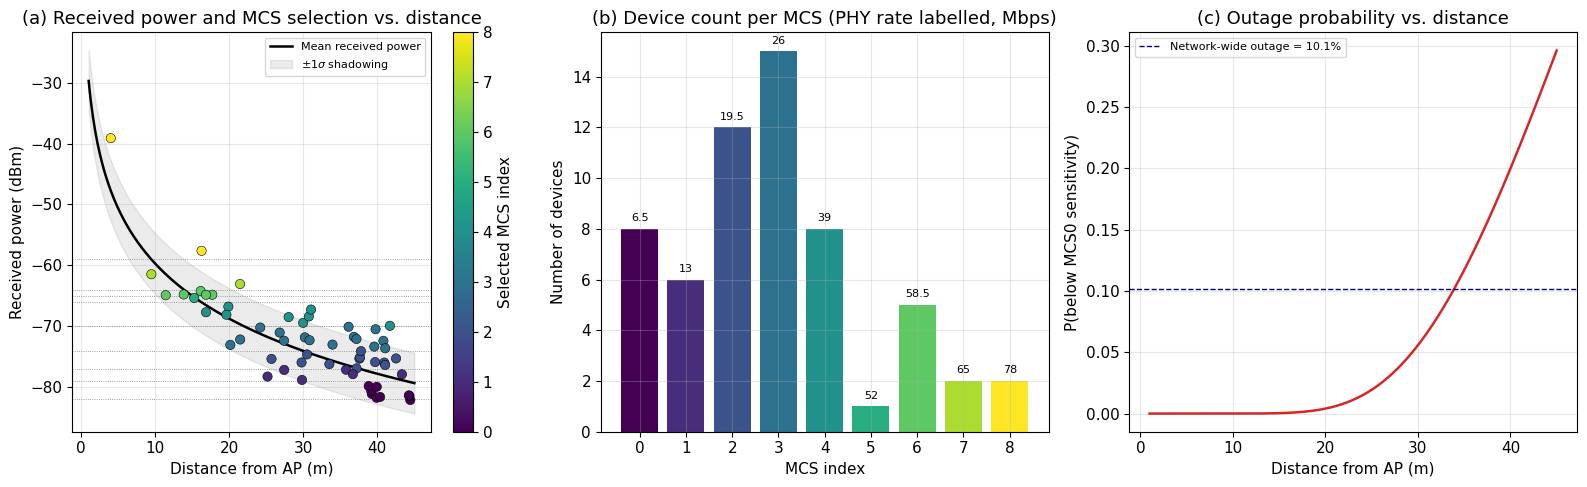

In [4]:
# ── Figure 18.1: link adaptation and outage probability ────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
d_grid = np.linspace(1, 45, 300)
for row in MCS_TABLE:
    ax.axhline(row['sens_dbm'], color='gray', lw=0.6, ls=':')
mean_prx = 17.0 - path_loss_db(d_grid)
ax.plot(d_grid, mean_prx, color='k', lw=1.8, label='Mean received power')
ax.fill_between(d_grid, mean_prx-5, mean_prx+5, color='k', alpha=0.08, label=r'$\pm1\sigma$ shadowing')
sc = ax.scatter(d, p_rx, c=np.clip(mcs_idx, 0, None), cmap='viridis', vmin=0, vmax=8, s=45,
                 edgecolor='k', linewidth=0.4, zorder=5)
cb = plt.colorbar(sc, ax=ax); cb.set_label('Selected MCS index')
ax.set_xlabel('Distance from AP (m)'); ax.set_ylabel('Received power (dBm)')
ax.set_title('(a) Received power and MCS selection vs. distance')
ax.legend(loc='upper right', fontsize=8)

ax = axes[1]
mcs_vals = [row['mcs'] for row in MCS_TABLE]
counts = [np.sum(mcs_idx==m) for m in mcs_vals]
rates_bar = [row['rate_mbps'] for row in MCS_TABLE]
bars = ax.bar([str(m) for m in mcs_vals], counts, color=plt.cm.viridis(np.linspace(0,1,9)))
ax.set_xlabel('MCS index'); ax.set_ylabel('Number of devices')
ax.set_title('(b) Device count per MCS (PHY rate labelled, Mbps)')
for b, r, c in zip(bars, rates_bar, counts):
    if c > 0:
        ax.text(b.get_x()+b.get_width()/2, c+0.3, f'{r:g}', ha='center', fontsize=8)

ax = axes[2]
outage_curve = [outage_probability(dd) for dd in d_grid]
ax.plot(d_grid, outage_curve, color='tab:red', lw=1.8)
ax.axhline(network_outage_analytic, color='navy', ls='--', lw=1,
           label=f'Network-wide outage = {network_outage_analytic:.1%}')
ax.set_xlabel('Distance from AP (m)'); ax.set_ylabel('P(below MCS0 sensitivity)')
ax.set_title('(c) Outage probability vs. distance')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_18_1_mcs.png', dpi=150, bbox_inches='tight')
plt.show()


### Analysis

Panel (a) shows why a single "Wi-Fi speed" number does not describe a
real deployment: received power falls steadily with distance (mean
curve), but shadowing scatters individual devices several dB above or
below that mean, so two devices at the *same* distance can land in
different MCS bands. Panel (b) shows the resulting spread in this
particular draw -- a discrete distribution across the MCS levels, not
a continuous one, since only nine distinct PHY rates exist in this
table. At 5 GHz with 17 dBm transmit power and an obstructed-office
exponent of 3.0, most devices in this 60-device sample land on the
lower half of the MCS table (MCS2-MCS4 dominate), with one of the 60
devices falling out of range altogether in this particular draw.

Panel (c) makes precise what that one out-of-range device does and does
not tell us: it is a single sample from a distribution, not a
statement about the network as a whole. Solving for the network-wide
outage probability -- the chance that a device drawn from the same
area-uniform placement and shadowing distribution falls below the
MCS0 threshold -- gives approximately 10\% by direct numerical
integration, confirmed by an independent 20,000-sample Monte Carlo
draw. Coverage past about 30 m is where this AP's link budget starts
to run out at 5 GHz: outage probability is under 1\% at 20 m but climbs
past 20\% by 40 m, an effect of the shorter range 5 GHz typically
offers compared with 2.4 GHz for the same transmit power and path-loss
exponent.

Two further points about the model itself are worth stating
explicitly. First, the MCS selection logic used here is a
receiver-sensitivity-based approximation of link adaptation: production
rate-adaptation algorithms also weigh packet-error-rate history, retry
counts, and vendor-specific logic, not just a static RSSI threshold
table. Second, this is a *PHY-layer* rate: it says nothing about the
throughput a station actually achieves once it must contend for the
channel with other devices -- that is the subject of Exercise 18.2.

**Key takeaway.** Wi-Fi link adaptation produces a discrete but wide
spread of per-device PHY rates driven by distance and shadowing.
Judging coverage from a single simulated snapshot can be misleading in
either direction; an outage-probability calculation, cross-checked by
Monte Carlo, gives a defensible network-level answer.

**Challenge tasks.**
1. Repeat the analysis at 2.4 GHz using an 802.11n HT MCS/sensitivity
   table instead. Compare not only received power, but the resulting
   MCS distribution, outage probability, and aggregate capacity across
   the two bands.
2. Add a second AP and assign each device to whichever AP gives the
   higher received power. How does the network-wide outage probability
   change?
3. The shadowing standard deviation was fixed at 5 dB. Sweep it from
   2 dB to 10 dB and plot how the outage probability at 30 m changes.
4. Replace the area-uniform device placement with a clustered
   placement (e.g., three "rooms" of devices at fixed distances). How
   does the MCS histogram change shape, and how does that compare with
   the area-uniform outage curve in panel (c)?

---
## Exercise 18.2 — CSMA/CA Contention: Saturation Throughput and the Cost of Sharing a Channel

### Background

Exercise 18.1 established the PHY-layer data rate a device can achieve
*if it has the channel to itself*. In any real deployment it does not:
Wi-Fi's Distributed Coordination Function (DCF) makes every station
sense the channel and back off with a random contention window before
transmitting, precisely so that simultaneous transmissions collide as
rarely as possible. That mechanism has a cost. As more stations share
one access point -- exactly what a dense IoT deployment (a smart
building, a hospital floor, an industrial cell) does -- collisions
become more likely and more airtime is spent on backoff and
retransmitted frames, so the *aggregate* throughput the AP can deliver
rises with the first few stations, then declines slowly as more are
added.

Bianchi's classic analytical model captures this with a
two-dimensional Markov chain that reduces, after some algebra, to a
small system of two equations that can be solved numerically. This
exercise implements that model to quantify how much of the
Exercise 18.1 PHY rate survives contention among $n$ stations.

### Model

Let $\tau$ be the probability a station transmits in a randomly chosen
slot, and $p$ the probability that a transmission it attempts
collides. Bianchi shows these satisfy

$$
\tau(p) = \frac{2(1-2p)}{(1-2p)(W+1) + pW\bigl(1-(2p)^m\bigr)},
\qquad
p = 1-(1-\tau)^{n-1},
$$

where $W = \mathrm{CW_{min}}+1$ and $m$ is the number of backoff
stages. The expression for $\tau(p)$ has a removable singularity at
$p=0.5$ (numerator and denominator both vanish there) but is
well-defined and continuous for every $p$ in the open interval
$(0,1)$; this exercise solves the fixed point over the full interval
rather than treating $p=0.5$ as a boundary. Solving it gives the
saturation throughput

$$
S = \frac{P_s P_{tr}\,E[\text{payload}]}
         {(1-P_{tr})\sigma + P_{tr}P_s T_s + P_{tr}(1-P_s)T_c},
$$

with $P_{tr}=1-(1-\tau)^n$, $P_s = n\tau(1-\tau)^{n-1}/P_{tr}$, and
$T_s$, $T_c$ the durations of a successful transmission and a
collision. Table 18.2 lists the parameters, including the standard
OFDM-PHY MAC timing values shared by 802.11a/g/n/ac/ax.

**Modelling scope.** Bianchi's model is a *saturation* model: it
assumes every station always has a frame ready to send. Real IoT
sensors are typically intermittent -- a periodic telemetry report every
few seconds, not a continuous backlog -- so the results below describe
a worst-case bound on MAC-layer capacity, useful for capacity planning
and for comparing configurations, rather than a literal claim that a
given number of *associated* devices by itself causes overload. Actual
overload depends on the offered load (packet-generation rate and size)
relative to this saturation ceiling.

| Parameter | Value | Meaning |
|---|---|---|
| Slot time $\sigma$ | 9 $\mu$s | IEEE 802.11 OFDM PHY |
| SIFS / DIFS | 16 / 34 $\mu$s | DIFS = SIFS + 2$\sigma$ |
| $\mathrm{CW_{min}}=15$ | $W=16$, $m=6$ | IEEE 802.11 OFDM-PHY default contention window |
| $\mathrm{CW_{min}}=31$ | $W=32$, $m=5$ | Larger initial window, common in some EDCA access-category configurations |
| Payload | 100 bytes | Representative IoT telemetry frame |
| PHY rate | 65 Mbps | MCS7 (20 MHz, 1 spatial stream) |

In [5]:
# ── Exercise 18.2: DCF saturation throughput vs. number of stations ────
payload_bits = 100*8
phy_rate = 65e6   # MCS7, from the 802.11ac table (also valid at 2.4 GHz under 802.11n)

configs = {'CWmin=15': (16, 6), 'CWmin=31': (32, 5)}
n_range = list(range(1, 201))
sweep = {}
for label, (W, m) in configs.items():
    S_mbps, tau_l, p_l = [], [], []
    for n in n_range:
        S, tau, p = dcf_throughput(n, W, m, payload_bits, phy_rate)
        S_mbps.append(S/1e6); tau_l.append(tau); p_l.append(p)
    sweep[label] = dict(n=np.array(n_range), S=np.array(S_mbps),
                         tau=np.array(tau_l), p=np.array(p_l))

for label, d_ in sweep.items():
    print(f"{label}: n=1 -> S={d_['S'][0]:.3f} Mbps (p={d_['p'][0]:.3f});  "
          f"n=200 -> S={d_['S'][-1]:.3f} Mbps (p={d_['p'][-1]:.3f})")

# crossover point between the two CWmin curves
diff = sweep['CWmin=31']['S'] - sweep['CWmin=15']['S']
crossover_idx = np.where(np.diff(np.sign(diff)))[0]
if len(crossover_idx):
    n_cross = n_range[crossover_idx[0]+1]
    print(f"\nCrossover: CWmin=31 overtakes CWmin=15 at n = {n_cross}")

print(f"\n{'n':>4s} {'S(CW=15)':>10s} {'S(CW=31)':>10s} {'p(CW=15)':>10s} {'p(CW=31)':>10s}")
for n in [1, 2, 5, 10, 11, 24, 50, 100, 200]:
    i = n - 1
    print(f"{n:4d} {sweep['CWmin=15']['S'][i]:10.3f} {sweep['CWmin=31']['S'][i]:10.3f} "
          f"{sweep['CWmin=15']['p'][i]:10.3f} {sweep['CWmin=31']['p'][i]:10.3f}")


CWmin=15: n=1 -> S=4.163 Mbps (p=0.000);  n=200 -> S=3.703 Mbps (p=0.759)
CWmin=31: n=1 -> S=3.028 Mbps (p=0.000);  n=200 -> S=3.916 Mbps (p=0.724)

Crossover: CWmin=31 overtakes CWmin=15 at n = 11

   n   S(CW=15)   S(CW=31)   p(CW=15)   p(CW=31)
   1      4.163      3.028      0.000      0.000
   2      4.783      3.977      0.105      0.057
   5      5.030      4.765      0.272      0.178
  10      4.963      4.955      0.384      0.290
  11      4.945      4.961      0.398      0.305
  24      4.749      4.887      0.504      0.426
  50      4.487      4.675      0.595      0.532
 100      4.153      4.362      0.678      0.629
 200      3.703      3.916      0.759      0.724


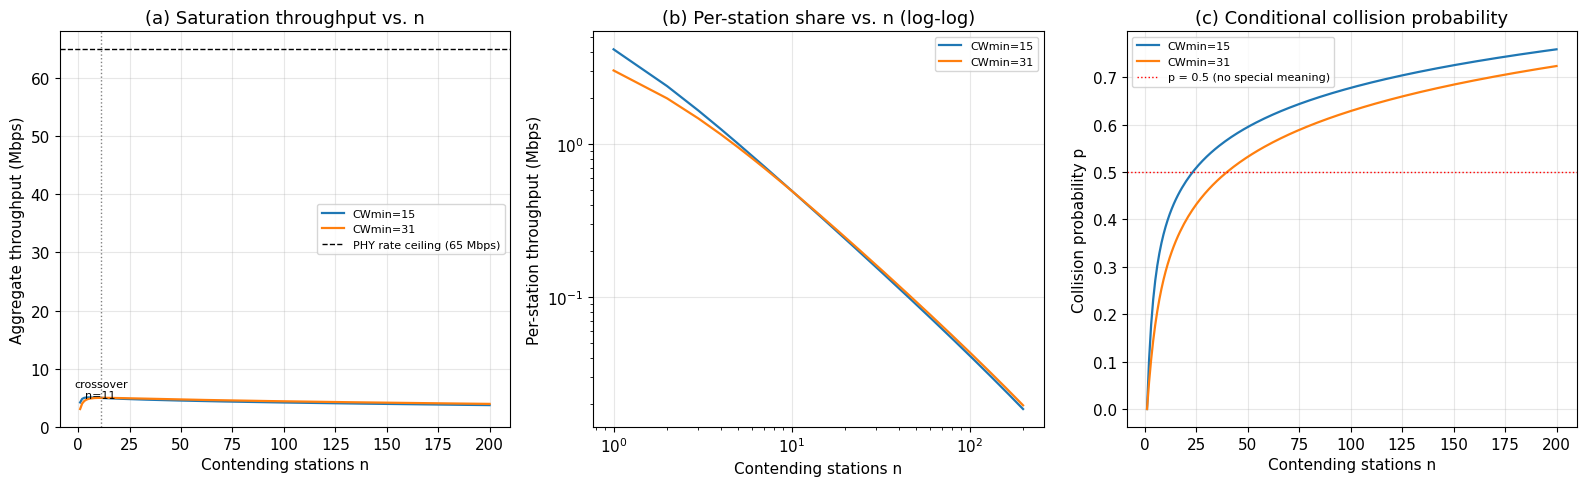

In [6]:
# ── Figure 18.2: aggregate throughput, per-station throughput, collision prob. ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'CWmin=15': 'tab:blue', 'CWmin=31': 'tab:orange'}

ax = axes[0]
for label, d_ in sweep.items():
    ax.plot(d_['n'], d_['S'], color=colors[label], label=label)
ax.axhline(phy_rate/1e6, color='k', ls='--', lw=1, label='PHY rate ceiling (65 Mbps)')
if len(crossover_idx):
    ax.axvline(n_cross, color='gray', ls=':', lw=1)
    ax.annotate(f'crossover\nn={n_cross}', xy=(n_cross, 4.9), fontsize=8, ha='center')
ax.set_xlabel('Contending stations n'); ax.set_ylabel('Aggregate throughput (Mbps)')
ax.set_title('(a) Saturation throughput vs. n'); ax.legend(fontsize=8)

ax = axes[1]
for label, d_ in sweep.items():
    ax.loglog(d_['n'], d_['S']/d_['n'], color=colors[label], label=label)
ax.set_xlabel('Contending stations n'); ax.set_ylabel('Per-station throughput (Mbps)')
ax.set_title('(b) Per-station share vs. n (log-log)'); ax.legend(fontsize=8)

ax = axes[2]
for label, d_ in sweep.items():
    ax.plot(d_['n'], d_['p'], color=colors[label], label=label)
ax.axhline(0.5, color='r', ls=':', lw=1, label='p = 0.5 (no special meaning)')
ax.set_xlabel('Contending stations n'); ax.set_ylabel('Collision probability p')
ax.set_title('(c) Conditional collision probability'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_18_2_csmaca.png', dpi=150, bbox_inches='tight')
plt.show()


### Analysis

Panel (a) shows the central result: aggregate throughput rises steeply
from a single station, peaks, and then declines *slowly and smoothly*
as more stations compete for the same channel -- there is no
discontinuity or breakdown at any particular $n$. The peak location
depends on $\mathrm{CW_{min}}$: with the default $\mathrm{CW_{min}}=15$,
throughput peaks at $n=5$ (5.030 Mbps); with the deliberately enlarged
$\mathrm{CW_{min}}=31$, the longer average backoff delays the peak to
$n=12$ (4.963 Mbps). With $\mathrm{CW_{min}}=15$, a single station
achieves only 4.16 Mbps out of a 65 Mbps PHY rate (MAC overhead --
DIFS, SIFS, backoff, ACK -- dominates for a 100-byte frame even with no
contention at all), and throughput is still 4.27 Mbps at $n=80$ and
3.70 Mbps at $n=200$: a gradual decline of roughly 26\% from the $n=5$
peak by the time 200 stations are contending, not a collapse. Panel (c)
confirms this directly: the conditional collision probability $p$
increases smoothly through 0.5 and beyond as $n$ grows (reaching 0.76
at $n=200$), with no change in the shape of the curve at that point --
$p=0.5$ is simply where the closed-form expression for $\tau(p)$ has a
removable singularity (with an exact limit $\tau(0.5)=4/(2(W+1)+mW)$),
not a stability boundary.

The two $\mathrm{CW_{min}}$ settings cross over at $n=11$
(Table 18.3): for ten or fewer stations, the smaller
$\mathrm{CW_{min}}=15$ gives marginally higher throughput because its
shorter average backoff wastes less time when collisions are rare; for
eleven or more, the larger $\mathrm{CW_{min}}=31$ wins because its
longer backoff reduces the *rate* at which collisions occur as
contention grows, more than compensating for the extra idle slots that
cost less than colliding frames do. This illustrates a general
contention-window design trade-off rather than a typical EDCA
access-category recommendation; real EDCA priority categories more
often use *smaller* contention windows than the default to favour
latency-sensitive traffic, the opposite direction from this comparison.
Panel (b) shows the resulting fairness consequence on a log-log scale:
per-station throughput falls off close to $1/n$ across the whole
range, so doubling the number of IoT devices on one AP roughly halves
what each one gets, regardless of which $\mathrm{CW_{min}}$ is in
effect.

The practical takeaway for an IoT network designer is a comparison, not
a threshold: at the density typical of a single dense floor of
sensors (tens to low hundreds of always-active stations), the
achievable *aggregate* airtime the DCF provides changes only modestly,
while the throughput available to any one station falls in rough
proportion to how many others are sharing the channel. Because the
model assumes every station is always backlogged, it represents a
worst case; a network of sensors that each report briefly once every
few seconds will typically see substantially less real contention than
this saturation ceiling implies, and the offered load -- not simply the
device count -- is what determines whether a deployment is actually
capacity-constrained.

**Key takeaway.** The PHY data rate from Exercise 18.1 is a ceiling
that MAC-layer contention erodes gradually, not abruptly, as more
stations share the channel; per-station throughput falls close to
$1/n$, and the choice of contention window trades a slightly lower
throughput at low station counts for a slower decline at high ones.

**Challenge tasks.**
1. Repeat the sweep with a 20-byte payload (a compact sensor reading)
   instead of 100 bytes. Does the crossover point between the two
   $\mathrm{CW_{min}}$ settings move, and in which direction?
2. Add RTS/CTS handshaking (extra overhead per attempt, but collisions
   become cheaper because they involve only the short RTS frame). Does
   RTS/CTS raise or lower the crossover $n$ found in this exercise?
3. Model a heterogeneous network where half the stations use MCS3 (26
   Mbps) and half use MCS7 (65 Mbps). How does the "performance
   anomaly" (slow stations dragging down fast ones) show up in the
   per-station throughput?
4. Replace the always-backlogged assumption with an intermittent
   traffic model (each station transmits with probability $q<1$ per
   opportunity) and compare the resulting throughput and collision
   probability against the saturation values computed here.

---
## Exercise 18.3 — BLE Connection Parameters: Balancing Power, Latency, and Throughput

### Background

Bluetooth Low Energy devices spend almost all of their life asleep.
Once connected, a central and a peripheral wake their radios briefly at
each *connection event*, exchange whatever data is pending, and go
back to sleep. Three parameters, negotiated when the connection is
formed, control that rhythm: the **connection interval** (how often
events occur), the **peripheral latency** (how many events the
peripheral is allowed to skip when it has nothing to send, 0-499), and
the **supervision timeout** (how long the link can go silent before it
is declared dead). Until Bluetooth Core Specification 6.2 (adopted
November 2025), the connection interval was limited to a baseline range
of 7.5 ms to 4 s in 1.25 ms steps; Core 6.2 introduced an optional
Shorter Connection Intervals (SCI) feature that lets supporting devices
negotiate intervals down to 375 $\mu$s in 125 $\mu$s steps, aimed at
latency-sensitive HID and sensor applications. This exercise models the
baseline 7.5 ms-4 s range, which remains the interval most currently
deployed BLE sensors, wearables, and beacons use.

This exercise builds a model of the trade-off between average current
draw, effective polling interval, and battery life -- the balance every
BLE application designer has to strike.

### Model

At the 1M PHY, one BLE packet carrying $M$ Link Layer payload bytes
takes $(10+M)\times 8/10^6$ seconds to transmit (1-byte preamble +
4-byte access address + 2-byte header + $M$-byte payload + 3-byte CRC,
all at 1 Mbps). This Link Layer payload is not the same quantity as an
application-level GATT notification value: a Handle Value Notification
carrying $N$ bytes of application data also carries a 4-byte L2CAP
header and a 3-byte ATT opcode-plus-handle, so $M = N+7$. For the
20-byte sensor sample used throughout this exercise, the on-air Link
Layer payload is therefore 27 bytes, not 20 -- a detail worth stating
explicitly, since the two quantities are easy to conflate and the
difference is not negligible at short connection intervals.

A minimal connection event consists of two packets and a single
inter-frame space: the peripheral receives an empty poll from the
central, then, after one 150 $\mu$s inter-frame space, transmits its
own data packet back; the event then closes. During that inter-frame
space the radio is turning around from receive to transmit, not
sleeping: it remains actively biased, drawing a current much closer to
its RX/TX current than to its sleep current, so the model must charge
it accordingly rather than treating it as free. With the poll
reception at $I_{\text{RX}}$, the turnaround at $I_{\text{IFS}}$, and
the response transmission at $I_{\text{TX}}$, the "charge" (current
$\times$ time) of one connection event is

$$
Q_{\text{active}} = T_{\text{ramp}}\,I_{\text{RX}}
  + t_{\text{poll}}\,I_{\text{RX}} + T_{\text{IFS}}\,I_{\text{IFS}}
  + t_{\text{resp}}\,I_{\text{TX}},
$$

where $T_{\text{ramp}}$ is a representative radio wake-up allowance.
The selected nRF52832 Product Specification does not publish a
separate turnaround-state current, so this exercise approximates
$I_{\text{IFS}}\approx 5.35$ mA, close to the published RX and TX
figures, on the grounds that a fast RX/TX turnaround keeps the radio's
analog front end powered rather than idling it; the Challenge Tasks
explore the sensitivity of the result to this approximation. If the
peripheral uses latency $L$, it is only obliged to wake every
$T_{\text{eff}} = T_{\text{interval}}(1+L)$ seconds, so the average
current is

$$
\bar I = \frac{Q_{\text{active}} +
(T_{\text{eff}}-T_{\text{active}})\,I_{\text{sleep}}}{T_{\text{eff}}}.
$$

Table 18.9 lists the parameters, taken from the Bluetooth Core
Specification (interval/latency/timeout ranges) and the Nordic
Semiconductor nRF52832 Product Specification (radio current draw). The
resulting battery-life figures are **idealized, radio-only upper
bounds**: they exclude MCU processing, sensor readout, flash writes,
retransmissions, oscillator start-up variability, voltage-regulator
efficiency, cell self-discharge, and temperature effects, all of which
reduce real-world battery life below these numbers.

| Parameter | Value | Source / meaning |
|---|---|---|
| Baseline connection interval range | 7.5 ms - 4 s | Bluetooth Core Spec., 1.25 ms steps |
| Peripheral latency range | 0 - 499 | Bluetooth Core Spec. |
| $I_{\text{TX}}$ (0 dBm) | 5.3 mA | nRF52832 Product Specification |
| $I_{\text{RX}}$ | 5.4 mA | nRF52832 Product Specification |
| $I_{\text{IFS}}$ (turnaround, approximate) | 5.35 mA | Approximated as the average of $I_{\text{TX}}$ and $I_{\text{RX}}$; not separately published |
| $I_{\text{sleep}}$ (System ON idle) | 1.9 $\mu$A | nRF52832, 32 kHz XO + RTC running |
| Battery capacity | 220 mAh | CR2032 coin cell, representative |
| GATT notification value $N$ | 20 bytes | e.g. a continuous motion/activity sensor sample |
| Link Layer payload $M=N+7$ | 27 bytes | 20-byte value + 4-byte L2CAP header + 3-byte ATT overhead |

In [7]:
# ── Exercise 18.3: BLE connection-parameter trade-off ──────────────────
app_payload_ble = 20          # bytes, GATT notification value
payload_ble = app_payload_ble + 7   # bytes, on-air Link Layer payload
battery_mAh = 220  # CR2032

t_active, q_active = ble_connection_event_charge(payload_ble)
print(f"Active radio time per connection event: {t_active*1e6:.1f} us "
      f"(RX poll + charged IFS turnaround + TX response)")

intervals_ms = np.array([7.5,10,15,20,30,50,75,100,150,200,300,500,750,1000,1500,2000,3000,4000])
i_avg_l, life_days_l, thr_l = [], [], []
for iv in intervals_ms:
    i_avg, eff, t_a = ble_avg_current(iv/1000, 0, payload_ble)
    i_avg_l.append(i_avg*1e6)
    life_days_l.append(battery_mAh/(i_avg*1000)/24)
    thr_l.append(8*app_payload_ble/(iv/1000)/1000)   # kbps, delivered app data, 1 packet/interval

print(f"\n{'Interval(ms)':>13s} {'I_avg(uA)':>10s} {'Life(days)':>11s} {'Life(years)':>12s} {'Throughput(kbps)':>17s}")
for iv, ia, ld, th in zip(intervals_ms, i_avg_l, life_days_l, thr_l):
    print(f"{iv:13.1f} {ia:10.2f} {ld:11.1f} {ld/365:12.2f} {th:17.3f}")

interval_fixed_ms = 30
latencies = np.array([0,1,2,4,8,16,32,64,128,256,499])
i_avg_lat, life_lat, eff_lat = [], [], []
for lat in latencies:
    i_avg, eff, t_a = ble_avg_current(interval_fixed_ms/1000, lat, payload_ble)
    i_avg_lat.append(i_avg*1e6); life_lat.append(battery_mAh/(i_avg*1000)/24/365); eff_lat.append(eff*1000)
print(f"\nAt interval={interval_fixed_ms} ms, varying peripheral latency "
      f"(idealized radio-only upper bound):")
for lat, ia, ld, ef in zip(latencies, i_avg_lat, life_lat, eff_lat):
    print(f"  latency={lat:4d}  eff.interval={ef:8.1f} ms  I_avg={ia:7.2f} uA  life={ld:6.2f} years")


Active radio time per connection event: 676.0 us (RX poll + charged IFS turnaround + TX response)

 Interval(ms)  I_avg(uA)  Life(days)  Life(years)  Throughput(kbps)
          7.5     483.50        19.0         0.05            21.333
         10.0     363.10        25.2         0.07            16.000
         15.0     242.70        37.8         0.10            10.667
         20.0     182.50        50.2         0.14             8.000
         30.0     122.30        75.0         0.21             5.333
         50.0      74.14       123.6         0.34             3.200
         75.0      50.06       183.1         0.50             2.133
        100.0      38.02       241.1         0.66             1.600
        150.0      25.98       352.8         0.97             1.067
        200.0      19.96       459.3         1.26             0.800
        300.0      13.94       657.6         1.80             0.533
        500.0       9.12      1004.7         2.75             0.320
        750.0    

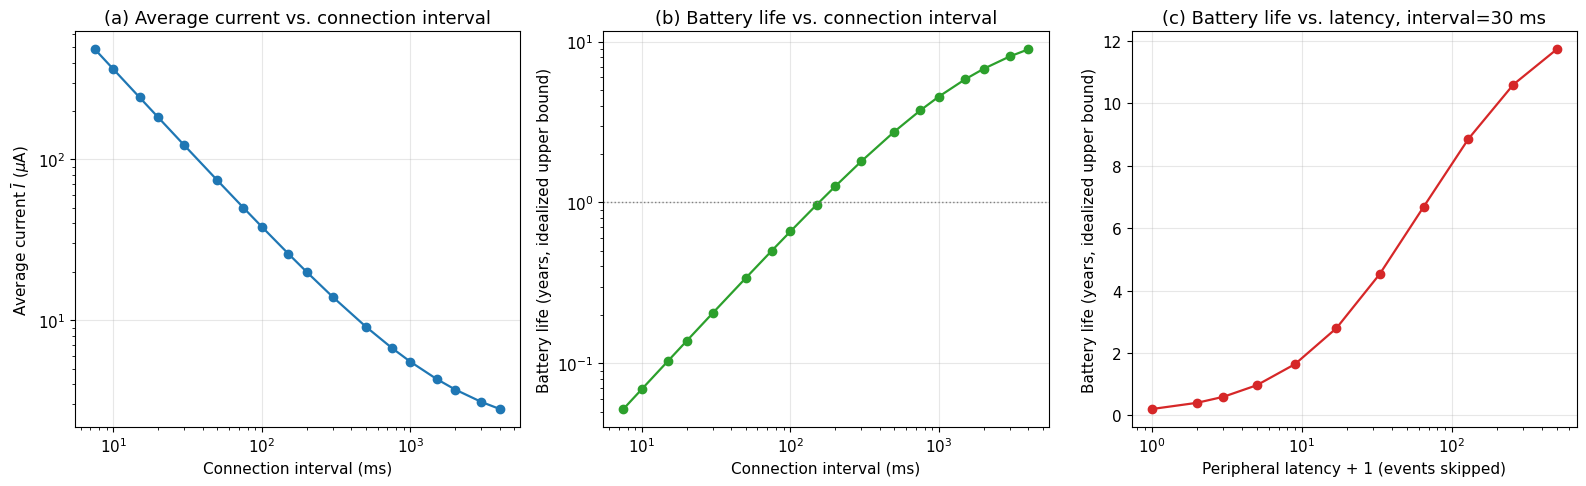

In [8]:
# ── Figure 18.3: current, battery life, and the latency lever ─────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.loglog(intervals_ms, i_avg_l, 'o-', color='tab:blue')
ax.set_xlabel('Connection interval (ms)'); ax.set_ylabel(r'Average current $\bar I$ ($\mu$A)')
ax.set_title('(a) Average current vs. connection interval')

ax = axes[1]
ax.loglog(intervals_ms, np.array(life_days_l)/365, 'o-', color='tab:green')
ax.axhline(1, color='gray', ls=':', lw=1)
ax.set_xlabel('Connection interval (ms)'); ax.set_ylabel('Battery life (years, idealized upper bound)')
ax.set_title('(b) Battery life vs. connection interval')

ax = axes[2]
ax.semilogx(latencies+1, life_lat, 'o-', color='tab:red')
ax.set_xlabel('Peripheral latency + 1 (events skipped)')
ax.set_ylabel('Battery life (years, idealized upper bound)')
ax.set_title(f'(c) Battery life vs. latency, interval={interval_fixed_ms} ms')

plt.tight_layout()
plt.savefig('fig_18_3_ble.png', dpi=150, bbox_inches='tight')
plt.show()


### Analysis

Panels (a)-(b) trace the same relationship two ways: average current
falls, and idealized battery life rises, close to linearly with the
connection interval on this log-log plot, because the active time and
charge per event are fixed while the sleep time between events grows
in direct proportion to the interval. At the fastest baseline interval,
7.5 ms, the model gives about 19 days on a CR2032; at the slowest,
4 s, it gives close to 9 years -- comparable to the cell's own
shelf-life and self-discharge timescale, which is the regime real
ultra-low-power BLE sensors (buttons, asset tags) are designed around,
and a reminder that beyond a few years a radio-only calculation stops
being a reliable predictor of real service life regardless of how
accurate the radio model itself is. A 30 ms interval, fast enough to
support a continuous motion or activity sensor stream at roughly
33 samples/second, lands at about 75 days, illustrating why a
continuously-sampling BLE sensor typically needs a rechargeable battery
or a much longer interval, not a coin cell sized for years of service.
These are, as Table 18.9 notes, radio-only upper bounds: a real product
will draw additional current for its MCU, its sensor, and its
regulator, and will fall short of these figures accordingly.

Two details are easy to miss when building a model like this, and both
matter quantitatively at a 30 ms interval. Treating the inter-frame
turnaround as free rather than charging it at $I_{\text{IFS}}$ would
understate average current; treating the GATT notification's 20-byte
application-level value as the full Link Layer payload, rather than
the actual 27 bytes once the L2CAP header and ATT overhead are
included, would understate it further. Together, both omissions would
put the current at 85.7 $\mu$A instead of the correct 122.3 $\mu$A --
an understatement of about 43% -- and would overstate the idealized
30 ms battery life at roughly 107 days instead of the correct 75 days,
about 30% too optimistic. More generally, every phase of a duty-cycled
radio's timeline needs an explicit current assumption, and every
on-air payload size needs to be traced back to what actually crosses
the antenna, not the size of the value an application handed to the
stack.

Panel (c) applies the second lever, peripheral latency, on top of a
fixed 30 ms interval. The benefit it shows depends entirely on what the
peripheral is sending, and on which direction of traffic is being
delayed. In this model, one notification is generated per connection
event that actually occurs, so raising the latency *reduces the
notification rate together with the power draw* -- the model captures
a device that is content to report less often, not a device that must
keep reporting at the original 30 ms rate while skipping unnecessary
wake-ups. That distinction matters in practice. For **sparse,
peripheral-initiated traffic** (a button press, an occasional alert, or
a once-per-second heart-rate summary sent over a much faster connection
interval), a real peripheral is not actually forced to wait out all
$L$ skipped events once it has something to send: it can attend the
next base connection event as soon as data becomes pending, so sparse
peripheral-originated traffic is largely unaffected in its own delivery
latency, and raising latency is close to a free power lever in this
direction: latency of 8 already extends idealized battery life from
0.21 to 1.64 years on this same 30 ms interval, and latency of 32
reaches 4.53 years. What a large latency *does* cost is
**central-to-peripheral responsiveness**: the central cannot reach the
peripheral any sooner than the peripheral's next scheduled wake-up, up
to $(1+L)$ intervals away, because the peripheral simply is not
listening on the events it has chosen to skip. For **continuous,
fixed-rate traffic** (the motion-sensor stream used above, or a
firmware update), where every connection event carries real data,
raising the latency does not save power without also reducing the
delivered sample rate. The supervision timeout constraint,
$\text{timeout} > (1+L)\times\text{interval}\times 2$, grows quickly
once both the interval and the latency are large -- at $L=499$ and a
30 ms interval, the effective interval is already 15 s, requiring a
supervision timeout just under the specification's 32 s ceiling, close
to the practical limit of how far this lever can be pushed at a short
base interval.

**Key takeaway.** In BLE, the connection interval sets the baseline
rate of responsiveness and throughput, while peripheral latency is a
power lever whose cost falls almost entirely on central-to-peripheral
responsiveness, not on delivering sparse peripheral-originated data,
which a peripheral can still send as soon as it becomes pending. Its
benefit is conditional: large for sparse, event-driven traffic where
most events would otherwise carry nothing, and negligible for
continuous, fixed-rate traffic, since there it always trades against
how often data is actually delivered. Every phase of the
connection-event timeline -- including brief inter-frame turnarounds --
and every on-air payload size -- including protocol overhead a GATT
value does not show at the application layer -- needs an explicit,
traced-through assumption; skipping either understates power draw.

**Challenge tasks.**
1. Recompute panels (a)-(b) for the Bluetooth 4.2+ Data Length
   Extension's maximum unfragmented notification: a 251-byte Link
   Layer payload corresponds to a 244-byte application-level value
   once the 7-byte L2CAP/ATT overhead is subtracted. How much
   idealized battery life is traded for the larger payload at a fixed
   interval?
2. $I_{\text{IFS}}$ was approximated as the average of the published
   TX and RX currents. Sweep it from $I_{\text{sleep}}$ up to
   $2\times I_{\text{RX}}$ and plot how sensitive the 30 ms
   average-current figure is to this choice.
3. Model a *continuous* 1-notification-per-second traffic source
   explicitly: choose the connection interval so that one notification
   fits per interval with latency 0, then show how much the delivered
   data rate falls if latency is increased instead of choosing a
   coarser base interval.
4. Recompute the model using the Bluetooth Core 6.2 Shorter Connection
   Intervals feature (down to 375 $\mu$s). At that interval, how does
   the fixed 676 $\mu$s active time per event constrain the shortest
   practical connection interval, and what does that imply for actual
   achievable polling rates?

---
## Exercise 18.4 — Bluetooth Channel Selection and Wi-Fi Coexistence in the 2.4 GHz Band

### Background

Wi-Fi and Bluetooth both operate in the license-exempt 2.4 GHz ISM
band, and a widely used Wi-Fi channel plan places non-overlapping
20 MHz channels at 1, 6, and 11 (other plans exist, particularly under
some European regulatory domains, but 1/6/11 is common enough to serve
as a representative case). It is tempting to conclude that
non-overlapping Wi-Fi channels leave Bluetooth's data channels mostly
clear. This exercise checks that assumption with the actual channel
arithmetic for both of Bluetooth's radio systems -- Bluetooth Low
Energy and Bluetooth Classic BR/EDR -- since they use materially
different channel plans and different minimum channel-map sizes.

Bluetooth LE uses 37 data channels spaced 2 MHz apart (with a small gap
reserved for an advertising channel), and the Bluetooth Core
Specification requires that a connection's channel map retain **at
least two** used channels. Bluetooth Classic BR/EDR uses 79 channels
spaced 1 MHz apart with Adaptive Frequency Hopping (AFH), and the Core
Specification requires **at least twenty** channels in the AFH map.
That ten-fold difference in the minimum channel-map size turns out
to matter more than the difference in channel spacing.

### Model

Wi-Fi channels 1, 6, and 11 are centred at 2412, 2437, and 2462 MHz and
occupy the band $[\text{centre}-10,\text{centre}+10]$ MHz each -- a
rectangular approximation of the occupied bandwidth; real spectral
masks roll off gradually rather than stopping at a hard edge, so this
somewhat overstates the sharpness of the boundary while giving a
reasonable estimate of the occupied channels. A Bluetooth channel is
classified as overlapping if it falls inside any Wi-Fi channel's
occupied band. If Wi-Fi channel $c$ is transmitting with probability
(duty cycle) $\delta$ at any given instant, then for a Bluetooth
transmission landing uniformly at random on one of $N_{\text{pool}}$
channels in the current channel map, of which $N_{\text{bad}}$ overlap
an active Wi-Fi channel, the collision probability is

$$
P_{\text{coll}} = \frac{N_{\text{bad}}}{N_{\text{pool}}}\,\delta.
$$

Without channel classification, $N_{\text{pool}}$ is the full channel
set (37 for LE, 79 for BR/EDR) and $N_{\text{bad}}$ is however many of
those channels overlap Wi-Fi's occupied bands. With classification, all
channels overlapping a persistently busy Wi-Fi channel are marked bad
and excluded -- but if fewer clear channels remain than the
specification's minimum, some bad channels must be re-admitted to the
map to satisfy that floor. Because this reasoning and the Monte Carlo
check below both follow directly from the same collision definition,
the Monte Carlo run is best read as a numerical consistency check on
the implementation, not as an independent empirical validation.

In [9]:
# ── Exercise 18.4: BLE and BR/EDR channel-overlap analysis ─────────────
def overlap_set(freqs, bands):
    overlap = set()
    for ch, (lo, hi) in bands.items():
        idx = np.where((freqs >= lo) & (freqs <= hi))[0]
        overlap |= set(idx.tolist())
    return overlap

ble_overlap = overlap_set(BLE_FREQS, WIFI_BANDS)
bredr_overlap = overlap_set(BREDR_FREQS, WIFI_BANDS)

ble_good = sorted(set(range(len(BLE_FREQS))) - ble_overlap)
bredr_good = sorted(set(range(len(BREDR_FREQS))) - bredr_overlap)

ble_forced_n = max(0, BLE_NMIN - len(ble_good))
bredr_forced_n = max(0, BREDR_NMIN - len(bredr_good))

print(f"BLE (37 channels, 2 MHz spacing):")
print(f"  Overlapping Wi-Fi 1/6/11: {len(ble_overlap)} / {len(BLE_FREQS)}")
print(f"  Always clear: {len(ble_good)}")
print(f"  Minimum channel-map size Nmin = {BLE_NMIN}  ->  "
      f"channels forced back into use: {ble_forced_n}")

print(f"\nBR/EDR (79 channels, 1 MHz spacing, AFH):")
print(f"  Overlapping Wi-Fi 1/6/11: {len(bredr_overlap)} / {len(BREDR_FREQS)}")
print(f"  Always clear: {len(bredr_good)}")
print(f"  Minimum channel-map size Nmin = {BREDR_NMIN}  ->  "
      f"channels forced back into use: {bredr_forced_n}")

delta = 0.4   # representative per-channel Wi-Fi duty cycle
p_ble_noclass = (len(ble_overlap)/len(BLE_FREQS)) * delta
p_ble_class = (ble_forced_n/BLE_NMIN) * delta if ble_forced_n > 0 else 0.0
p_bredr_noafh = (len(bredr_overlap)/len(BREDR_FREQS)) * delta
p_bredr_afh = (bredr_forced_n/BREDR_NMIN) * delta

print(f"\nAt Wi-Fi duty cycle delta={delta:.0%}:")
print(f"  BLE:    no classification P(coll)={p_ble_noclass:.3f}   "
      f"with classification P(coll)={p_ble_class:.3f}")
print(f"  BR/EDR: no AFH P(coll)={p_bredr_noafh:.3f}   with AFH P(coll)={p_bredr_afh:.3f}")

# Monte Carlo consistency check
rng = np.random.default_rng(7)
T = 200_000
wifi_busy = rng.random((T, 3)) < delta

def simulate(freqs, pool_idx):
    hops = rng.choice(pool_idx, size=T)
    coll = np.zeros(T, dtype=bool)
    for j, ch in enumerate([1, 6, 11]):
        lo, hi = WIFI_BANDS[ch]
        in_band = (freqs[hops] >= lo) & (freqs[hops] <= hi)
        coll |= (in_band & wifi_busy[:, j])
    return coll.mean()

ble_all_idx = np.arange(len(BLE_FREQS))
ble_class_idx = np.array(ble_good)  # 6 clear channels already exceed Nmin=2
bredr_all_idx = np.arange(79)
bredr_forced_list = sorted(bredr_overlap)[:bredr_forced_n]
bredr_afh_pool = np.array(sorted(set(bredr_good) | set(bredr_forced_list)))

print(f"\nMonte Carlo consistency check (T={T:,}):")
print(f"  BLE    no-classification: {simulate(BLE_FREQS, ble_all_idx):.4f}  "
      f"(analytic {p_ble_noclass:.4f})")
print(f"  BLE    classified:        {simulate(BLE_FREQS, ble_class_idx):.4f}  "
      f"(analytic {p_ble_class:.4f})")
print(f"  BR/EDR no-AFH:            {simulate(BREDR_FREQS, bredr_all_idx):.4f}  "
      f"(analytic {p_bredr_noafh:.4f})")
print(f"  BR/EDR AFH:               {simulate(BREDR_FREQS, bredr_afh_pool):.4f}  "
      f"(analytic {p_bredr_afh:.4f})")


BLE (37 channels, 2 MHz spacing):
  Overlapping Wi-Fi 1/6/11: 31 / 37
  Always clear: 6
  Minimum channel-map size Nmin = 2  ->  channels forced back into use: 0

BR/EDR (79 channels, 1 MHz spacing, AFH):
  Overlapping Wi-Fi 1/6/11: 63 / 79
  Always clear: 16
  Minimum channel-map size Nmin = 20  ->  channels forced back into use: 4

At Wi-Fi duty cycle delta=40%:
  BLE:    no classification P(coll)=0.335   with classification P(coll)=0.000
  BR/EDR: no AFH P(coll)=0.319   with AFH P(coll)=0.080

Monte Carlo consistency check (T=200,000):
  BLE    no-classification: 0.3355  (analytic 0.3351)
  BLE    classified:        0.0000  (analytic 0.0000)
  BR/EDR no-AFH:            0.3179  (analytic 0.3190)
  BR/EDR AFH:               0.0799  (analytic 0.0800)


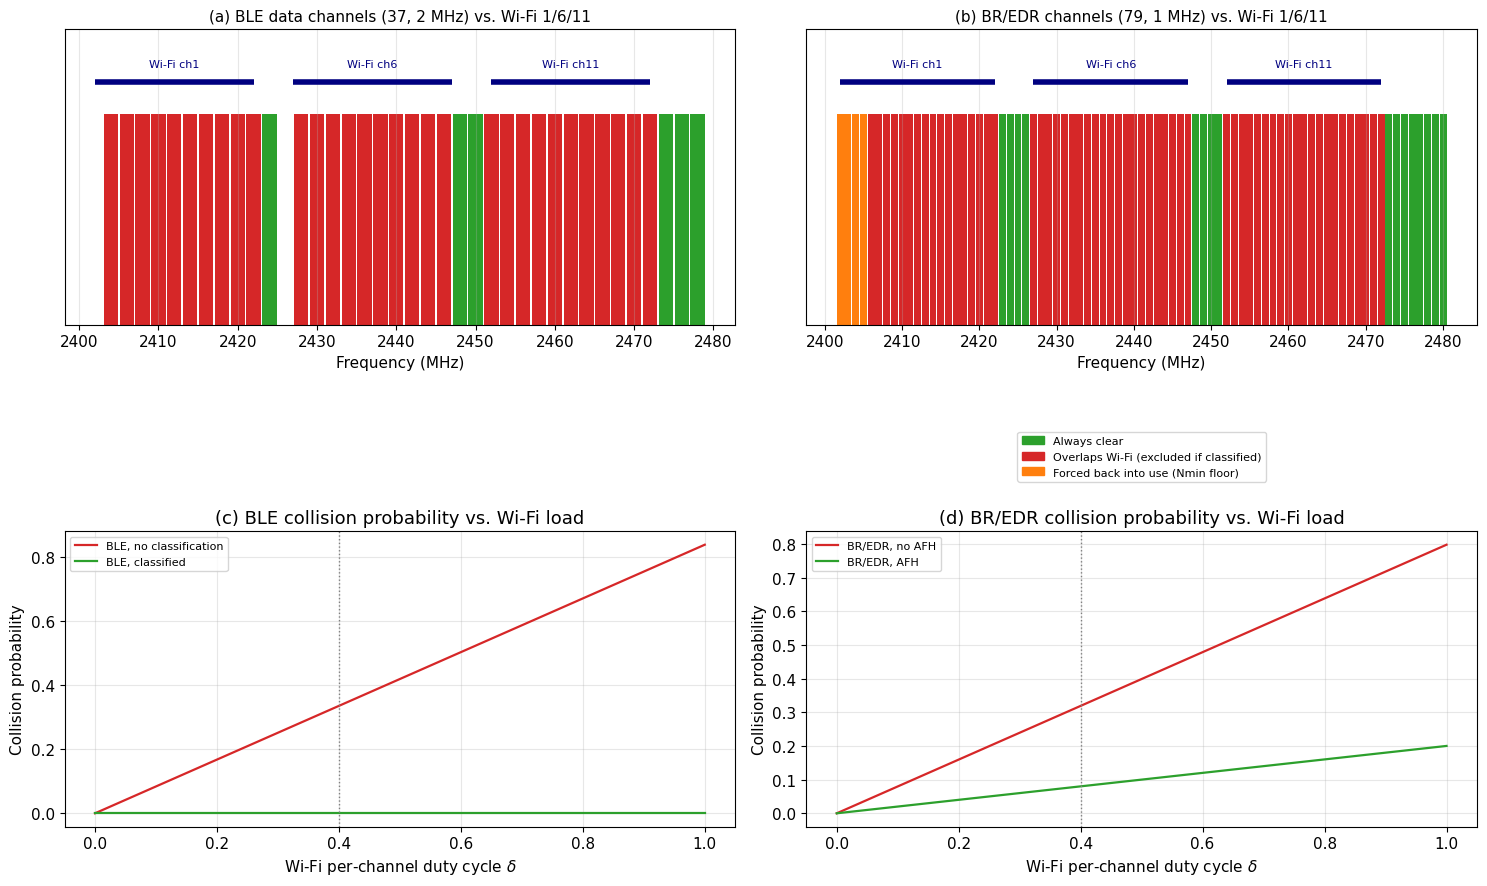

In [10]:
# ── Figure 18.4: channel maps and collision probability vs. duty cycle ─
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

def plot_spectrum(ax, freqs, overlap, forced, title, chan_width):
    status = np.array(['good']*len(freqs), dtype=object)
    for c in overlap: status[c] = 'bad'
    for c in forced: status[c] = 'forced'
    colors_map = {'good':'tab:green', 'bad':'tab:red', 'forced':'tab:orange'}
    for k in range(len(freqs)):
        ax.bar(freqs[k], 1, width=chan_width, color=colors_map[status[k]], edgecolor='none')
    for ch, (lo, hi) in WIFI_BANDS.items():
        ax.plot([lo, hi], [1.15, 1.15], color='navy', lw=4, solid_capstyle='butt')
        ax.text((lo+hi)/2, 1.22, f'Wi-Fi ch{ch}', ha='center', fontsize=8, color='navy')
    ax.set_ylim(0, 1.4); ax.set_xlabel('Frequency (MHz)'); ax.set_yticks([])
    ax.set_title(title, fontsize=11)

plot_spectrum(axes[0,0], BLE_FREQS, ble_overlap, [], '(a) BLE data channels (37, 2 MHz) vs. Wi-Fi 1/6/11', 1.8)
plot_spectrum(axes[0,1], BREDR_FREQS, bredr_overlap, bredr_forced_list,
              '(b) BR/EDR channels (79, 1 MHz) vs. Wi-Fi 1/6/11', 0.9)

from matplotlib.patches import Patch
legend_handles = [Patch(color='tab:green', label='Always clear'),
                   Patch(color='tab:red', label='Overlaps Wi-Fi (excluded if classified)'),
                   Patch(color='tab:orange', label='Forced back into use (Nmin floor)')]
axes[0,1].legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.55),
                  ncol=1, fontsize=8)

ax = axes[1,0]
deltas = np.linspace(0, 1, 40)
ax.plot(deltas, (len(ble_overlap)/len(BLE_FREQS))*deltas, color='tab:red', label='BLE, no classification')
ax.plot(deltas, np.zeros_like(deltas) if ble_forced_n==0 else (ble_forced_n/BLE_NMIN)*deltas,
        color='tab:green', label='BLE, classified')
ax.axvline(delta, color='gray', ls=':', lw=1)
ax.set_xlabel('Wi-Fi per-channel duty cycle ' + r'$\delta$')
ax.set_ylabel('Collision probability')
ax.set_title('(c) BLE collision probability vs. Wi-Fi load')
ax.legend(fontsize=8)

ax = axes[1,1]
ax.plot(deltas, (len(bredr_overlap)/79)*deltas, color='tab:red', label='BR/EDR, no AFH')
ax.plot(deltas, (bredr_forced_n/BREDR_NMIN)*deltas, color='tab:green', label='BR/EDR, AFH')
ax.axvline(delta, color='gray', ls=':', lw=1)
ax.set_xlabel('Wi-Fi per-channel duty cycle ' + r'$\delta$')
ax.set_ylabel('Collision probability')
ax.set_title('(d) BR/EDR collision probability vs. Wi-Fi load')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_18_4_coexistence.png', dpi=150, bbox_inches='tight')
plt.show()


### Analysis

The channel arithmetic in panels (a)-(b) shows that non-overlapping
Wi-Fi channels overlap a substantial fraction of *both* Bluetooth
channel plans: 31 of BLE's 37 data channels (84\%) and 63 of BR/EDR's
79 channels (80\%) fall inside the occupied bands of Wi-Fi channels 1,
6, and 11 combined, leaving only 6 BLE channels and 16 BR/EDR channels
permanently clear. On that overlap fraction alone, the two protocols
look similarly exposed. What changes the outcome entirely is each
specification's minimum channel-map size. BLE's floor of 2 channels is
well below the 6 channels that are always clear, so a channel
classifier can exclude all 31 overlapping channels and still satisfy
the specification -- in this idealized model, with perfect, static
classification, the collision probability with classification enabled
falls to **zero** (panel c), confirmed by the Monte Carlo check.
BR/EDR's floor of 20 channels is *larger* than its 16 always-clear
channels, so AFH is mathematically unable to exclude every overlapping
channel: it must re-admit 4 of them, leaving a **residual 8\%
collision probability** at a 40\% Wi-Fi duty cycle (panel d) that no
amount of classifier accuracy can remove.

This idealized zero for BLE assumes perfect, persistent classification
of which channels are busy and takes the bare minimum of 2 channels as
sufficient; real BLE stacks generally keep more than the specification
minimum in the channel map for robustness against sources of
interference other than a single co-located Wi-Fi network, and channel
classification is typically performed only by the central device based
on recent packet statistics, not a perfect real-time map. The
qualitative conclusion nonetheless holds: BLE's much smaller minimum
channel-map requirement gives its channel-selection mechanism room to
avoid a persistently busy Wi-Fi deployment far more completely than
BR/EDR's AFH ever can, purely as a consequence of the two
specifications' different minimum channel counts -- 2 against 20 -- not
because of any difference in classifier sophistication.

**Key takeaway.** Under the assumed three-channel Wi-Fi 1/6/11
deployment, both Bluetooth channel plans overlap a similar fraction of
the non-overlapping Wi-Fi channels, but their very different minimum
channel-map sizes (2 for BLE, 20 for BR/EDR) mean channel
classification can, in principle, fully clear BLE of Wi-Fi interference
while BR/EDR's AFH retains some collision risk. With fewer busy Wi-Fi
channels (Challenge 1), even BR/EDR's larger floor can be satisfied
without forcing any channel back into use.

**Challenge tasks.**
1. Recompute the analysis for a Wi-Fi deployment using only channel 6
   (a single busy AP). How much larger is the pool of always-clear
   channels for each Bluetooth variant, and does BR/EDR's forced-back
   channel count reach zero?
2. Rather than correlating the three Wi-Fi channels' duty cycles (which
   does not change a single hop's marginal collision probability, since
   each hop can only ever land in the band of at most one Wi-Fi
   channel), model *consecutive* Bluetooth transmissions on the same
   channel and estimate the distribution of consecutive-loss burst
   lengths as a function of $\delta$.
3. The rectangular Wi-Fi band approximation used here has a hard edge
   at $\pm10$ MHz. Replace it with a simple linear roll-off of
   collision probability over a few MHz at each edge and see how much
   the always-clear channel counts change for BLE and BR/EDR.
4. Model a lost Bluetooth packet's retry cost: the expected total
   number of transmission attempts is $1/(1-P_{\text{coll}})$,
   equivalently an expected $P_{\text{coll}}/(1-P_{\text{coll}})$
   *retransmissions* beyond the first attempt. Plot the resulting
   effective throughput loss for BR/EDR with and without AFH across
   the full $\delta$ sweep from panel (d).

---
## Summary

| Exercise | Technique | Practical benefit |
|----------|-----------|-------------------|
| 18.1 | IEEE 802.11ac MCS table (5 GHz, MCS0-8) + area-uniform placement + outage probability | Realistic PHY-rate distribution and a defensible, Monte-Carlo-checked coverage figure |
| 18.2 | Bianchi's DCF fixed point, solved over the full probability range | Quantifies the gradual, continuous erosion of throughput as contention grows |
| 18.3 | BLE connection-event energy model (RX/TX-separated, real SoC current draw) | Turns connection interval/latency choices into concrete, honestly-bounded battery-life numbers |
| 18.4 | BLE and BR/EDR channel-overlap analysis, Monte Carlo cross-checked | Explains why BLE's channel-map minimum lets it clear Wi-Fi interference more completely than BR/EDR's AFH |

All four exercises share a common thread: replacing a qualitative
claim about Wi-Fi or Bluetooth performance with a number derived from
the underlying IEEE 802.11 and Bluetooth Core Specification parameters,
stating the assumptions each model rests on, and cross-checking closed-form
results against independent numerical computation wherever practical.
Section 18.4 of this chapter turns to real-world deployments where
these same trade-offs -- PHY rate versus range, throughput versus
contention, power versus latency, and channel-map size versus
coexistence -- are weighed in practice.